In [ ]:
# Notebook 05 — Extracción de Entidades y Temas

**Reto 7 — Análisis de Datos No Estructurados y Redes Sociales**

## 🎯 Objetivo
1. **NER (Named Entity Recognition)**: extraer personas, organizaciones, lugares y productos mencionados en los tweets.
2. **LDA (Latent Dirichlet Allocation)**: descubrir los temas latentes en el corpus.
3. Visualizar los resultados y extraer insights accionables.

## 📌 Input
- `data/processed/tweets_con_sentimiento_20260920.csv`

## 📌 Output
- `data/processed/tweets_entidades_20260920.csv`
- `data/processed/tweets_topicos_20260920.csv`
- `outputs/figuras/05_*.png`
- `outputs/reportes/05_ner_lda_resumen.md`

In [3]:
# ============================================
# Imports y configuración
# ============================================
import re
import sys
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# NER
import spacy

# LDA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# --- pyLDAvis (para visualización interactiva) ---
PYLDAVIS_OK = False
try:
    import pyLDAvis
    # En pyLDAvis 3.x el submódulo .sklearn ya no existe.
    # Se comprueba su disponibilidad dinámicamente.
    try:
        import pyLDAvis.sklearn  # para versiones antiguas (<3)
        PYLDAVIS_OK = "sklearn"
    except ImportError:
        PYLDAVIS_OK = "base"  # versión 3.x → solo pyLDAvis base
    print(f"✅ pyLDAvis {pyLDAvis.__version__} disponible (modo: {PYLDAVIS_OK})")
except ImportError:
    print("⚠️ pyLDAvis no instalado. Se omitirá la visualización interactiva.")
    print("   Instala con: pip install pyLDAvis")

tqdm.pandas()
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Rutas ---
def encontrar_raiz_proyecto():
    cwd = Path.cwd()
    for candidato in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent]:
        if (candidato / "requirements.txt").exists() and (candidato / "data").exists():
            return candidato
    return cwd.parent

BASE_DIR = encontrar_raiz_proyecto()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
FIGURAS = BASE_DIR / "outputs" / "figuras"
REPORTES = BASE_DIR / "outputs" / "reportes"

FIGURAS.mkdir(parents=True, exist_ok=True)
REPORTES.mkdir(parents=True, exist_ok=True)

print(f"📁 BASE_DIR: {BASE_DIR}")

✅ pyLDAvis 3.4.0 disponible (modo: base)
📁 BASE_DIR: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados


In [4]:
# ============================================
# Cargar corpus con sentimiento
# ============================================
archivos = sorted(
    DATA_PROCESSED.glob("tweets_con_sentimiento_*.csv"),
    key=lambda x: x.stat().st_mtime,
    reverse=True,
)

if not archivos:
    raise FileNotFoundError("❌ No se encontró tweets_con_sentimiento_*.csv")

RUTA = archivos[0]
print(f"📂 Cargando: {RUTA.name}")
df = pd.read_csv(RUTA, encoding="utf-8-sig")

print(f"✅ Shape: {df.shape}")
print(f"📋 Columnas: {list(df.columns)}")
display(df.head(3))

📂 Cargando: tweets_con_sentimiento_20260920.csv
✅ Shape: (100000, 17)
📋 Columnas: ['date', 'fecha', 'username', 'texto_limpio', 'idioma', 'tokens', 'lemas', 'tb_polarity', 'tb_subjectivity', 'vader_pos', 'vader_neu', 'vader_neg', 'vader_compound', 'sentimiento_textblob', 'sentimiento_vader', 'like_count', 'retweet_count']


,date,fecha,username,texto_limpio,idioma,tokens,lemas,tb_polarity,tb_subjectivity,vader_pos,vader_neu,vader_neg,vader_compound,sentimiento_textblob,sentimiento_vader,like_count,retweet_count
0,2023-03-29 22:58:21+00:00,2023-03-29,RealProfitPros,free ai marketing and automation tools strategies and collaboration launching new week chatgpt,en,"['free', 'marketing', 'automation', 'tools', 'strategies', 'collaboration', 'launching', 'week']","['freir', 'marketing', 'automation', 'tools', 'strategies', 'collaboration', 'launching', 'week']",0.268182,0.627273,0.216,0.784,0.0,0.5106,positivo,positivo,0.0,0.0
1,2023-03-29 22:58:18+00:00,2023-03-29,AmyLouWho321,chat gpt says it s,en,"['chat', 'says']","['chat', 'says']",0.000000,0.000000,0.000,1.000,0.0,0.0000,neutral,neutral,0.0,0.0
2,2023-03-29 22:57:53+00:00,2023-03-29,yjleon1976,chat with any pdf check out how this new ai quickly answers questions from your pdfs perfect for students researchers and other curious minds rese...,en,"['chat', 'pdf', 'check', 'quickly', 'answers', 'questions', 'pdfs', 'perfect', 'students', 'researchers', 'curious', 'minds', 'research', 'chatpdf']","['chat', 'pdf', 'check', 'quickly', 'answer', 'questions', 'pdfs', 'perfect', 'students', 'researchers', 'curious', 'minds', 'research', 'chatpdf']",0.248939,0.665909,0.194,0.806,0.0,0.7184,positivo,positivo,0.0,0.0


In [5]:
# ============================================
# Cargar modelo SpaCy para NER
# ============================================
try:
    nlp_ner = spacy.load("en_core_web_sm")
    print("✅ en_core_web_sm cargado (con NER)")
except OSError:
    print("📥 Instalando en_core_web_sm...")
    import subprocess
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp_ner = spacy.load("en_core_web_sm")
    print("✅ en_core_web_sm listo")

# Tipos de entidades que nos interesan
TIPOS_INTERES = {
    "PERSON": "👤 Personas",
    "ORG":    "🏢 Organizaciones",
    "GPE":    "🌍 Lugares",
    "PRODUCT":"📦 Productos",
    "EVENT":  "🎉 Eventos",
    "WORK_OF_ART": "🎨 Obras",
    "NORP":   "👥 Grupos",
    "MONEY":  "💰 Dinero",
}

print(f"\n📋 Tipos de entidades que extraeremos: {list(TIPOS_INTERES.keys())}")

✅ en_core_web_sm cargado (con NER)

📋 Tipos de entidades que extraeremos: ['PERSON', 'ORG', 'GPE', 'PRODUCT', 'EVENT', 'WORK_OF_ART', 'NORP', 'MONEY']


In [6]:
# ============================================
# Función de extracción de entidades
# ============================================
def extraer_entidades(texto):
    """Extrae entidades nombradas del texto con SpaCy.
    Devuelve lista de tuplas (texto_entidad, tipo).
    """
    if not isinstance(texto, str) or not texto.strip():
        return []
    doc = nlp_ner(texto)
    return [(ent.text.strip(), ent.label_) for ent in doc.ents
            if ent.label_ in TIPOS_INTERES]


# --- Prueba rápida ---
ejemplos = [
    "I love ChatGPT by OpenAI, it's amazing for students in New York.",
    "Microsoft invested billions in OpenAI to compete with Google.",
    "Elon Musk founded xAI in California last year.",
]

print("🧪 Prueba de NER:")
for t in ejemplos:
    ents = extraer_entidades(t)
    print(f"\n  Texto: {t}")
    for ent, tipo in ents:
        print(f"    → {ent} ({tipo})")

🧪 Prueba de NER:

  Texto: I love ChatGPT by OpenAI, it's amazing for students in New York.
    → OpenAI (GPE)
    → New York (GPE)

  Texto: Microsoft invested billions in OpenAI to compete with Google.
    → Microsoft (ORG)
    → OpenAI (GPE)
    → Google (ORG)

  Texto: Elon Musk founded xAI in California last year.
    → Elon Musk (PERSON)
    → California (GPE)


In [7]:
# ============================================
# Aplicar NER al corpus
# ============================================
# Para 100k tweets, SpaCy tarda ~5-8 min. Si quieres acelerar:
# LIMITE = 30_000  # ← descomenta para probar rápido
LIMITE = None

if LIMITE:
    df_ner = df.sample(n=min(LIMITE, len(df)), random_state=42).copy()
    print(f"⚠️ Usando muestra de {len(df_ner):,} tweets")
else:
    df_ner = df.copy()
    print(f"🔍 Extrayendo entidades de {len(df_ner):,} tweets...")

df_ner["entidades"] = df_ner["texto_limpio"].progress_apply(extraer_entidades)

# Estadísticas
n_ents = df_ner["entidades"].str.len().sum()
n_tweets_con_ents = (df_ner["entidades"].str.len() > 0).sum()

print(f"\n✅ Extracción completada")
print(f"📊 Total entidades extraídas: {n_ents:,}")
print(f"📊 Tweets con al menos 1 entidad: {n_tweets_con_ents:,} ({n_tweets_con_ents/len(df_ner)*100:.1f}%)")

🔍 Extrayendo entidades de 100,000 tweets...


  0%|          | 0/100000 [00:00<?, ?it/s]


✅ Extracción completada
📊 Total entidades extraídas: 64,268
📊 Tweets con al menos 1 entidad: 48,494 (48.5%)


In [8]:
# ============================================
# Top entidades por tipo
# ============================================
# Aplanar todas las entidades
todas = []
for lista in df_ner["entidades"]:
    todas.extend(lista)

# DataFrame de entidades
df_ents = pd.DataFrame(todas, columns=["entidad", "tipo"])
df_ents["entidad_norm"] = df_ents["entidad"].str.lower().str.strip()

print(f"📊 Total menciones: {len(df_ents):,}")
print(f"📊 Entidades únicas: {df_ents['entidad_norm'].nunique():,}")
print(f"\n📋 Distribución por tipo:")
print(df_ents["tipo"].value_counts())

📊 Total menciones: 64,268
📊 Entidades únicas: 10,718

📋 Distribución por tipo:
tipo
ORG            44223
PERSON         11334
GPE             4444
NORP            2251
PRODUCT         1277
WORK_OF_ART      590
MONEY            117
EVENT             32
Name: count, dtype: int64


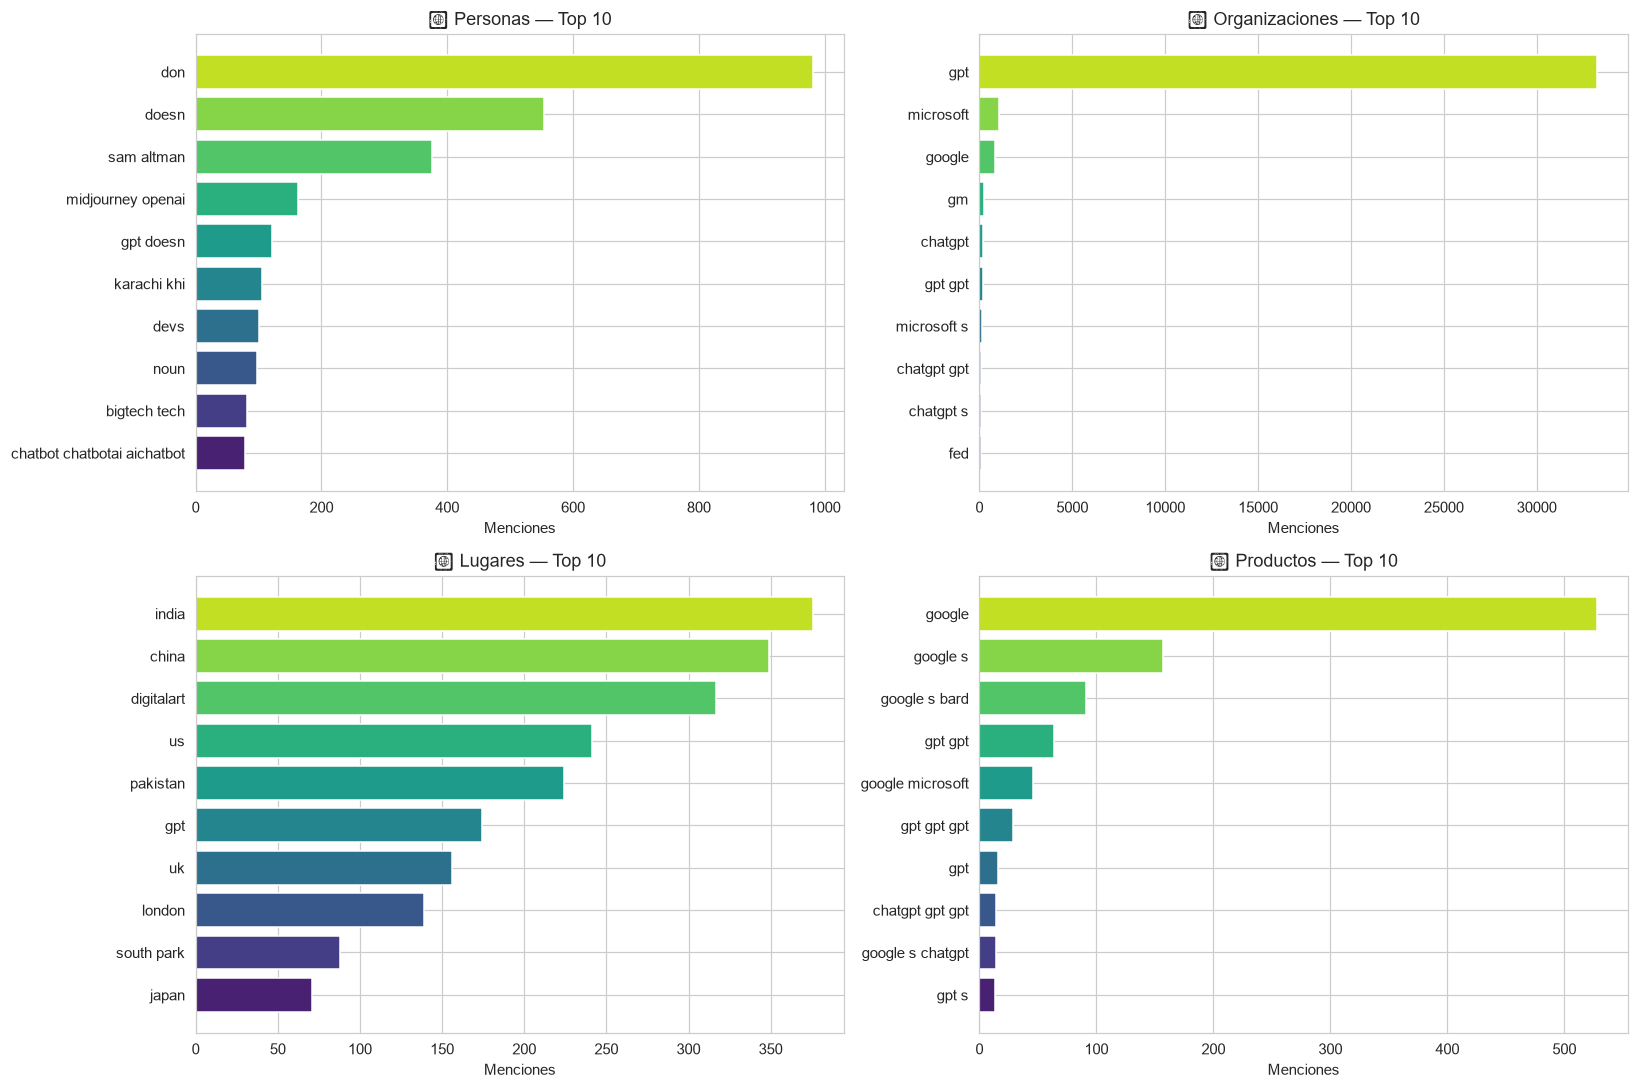

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras\05_top_entidades_por_tipo.png


In [9]:
# ============================================
# Visualización: Top 10 entidades por tipo
# ============================================
tipos_top = ["PERSON", "ORG", "GPE", "PRODUCT"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, tipo in zip(axes, tipos_top):
    sub = df_ents[df_ents["tipo"] == tipo]
    top = sub["entidad"].value_counts().head(10)

    if len(top) == 0:
        ax.text(0.5, 0.5, f"Sin entidades de tipo {tipo}",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(TIPOS_INTERES[tipo])
        continue

    colores = sns.color_palette("viridis", len(top))
    ax.barh(top.index[::-1], top.values[::-1], color=colores)
    ax.set_title(f"{TIPOS_INTERES[tipo]} — Top 10", fontsize=12)
    ax.set_xlabel("Menciones")

plt.tight_layout()
ruta_fig = FIGURAS / "05_top_entidades_por_tipo.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

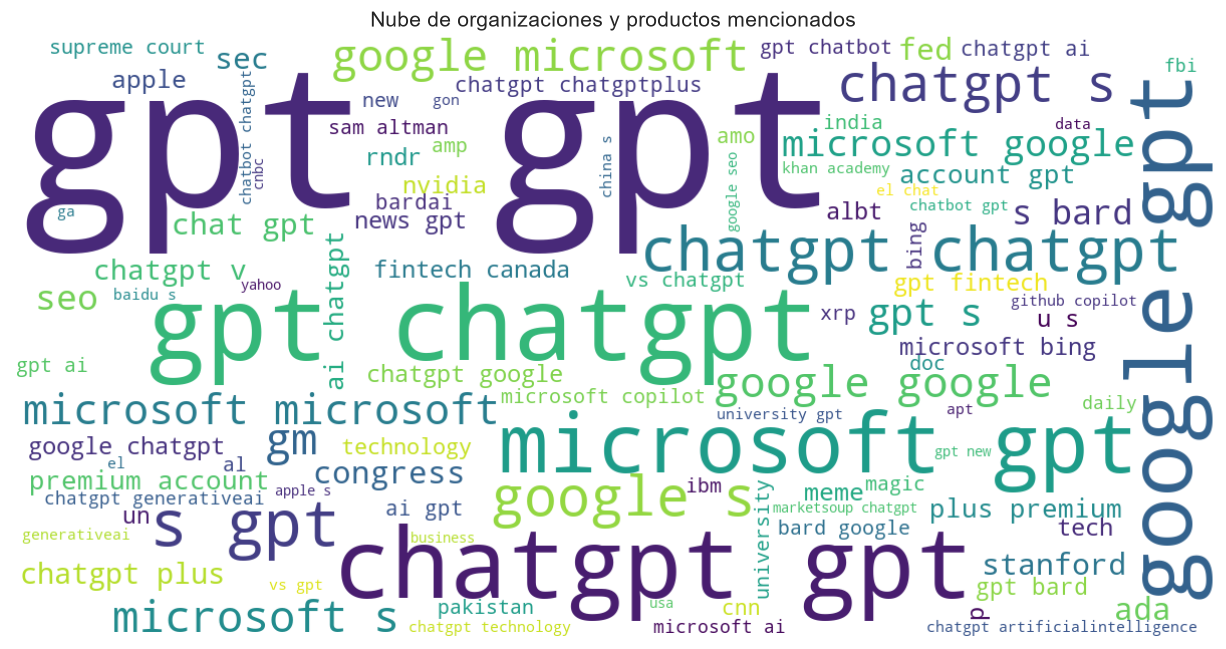

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras\05_wordcloud_entidades.png


In [10]:
# ============================================
# Nube de palabras con entidades
# ============================================
try:
    from wordcloud import WordCloud

    # Solo organizaciones y productos (los más relevantes para el dominio IA)
    texto_ents = " ".join(
        df_ents[df_ents["tipo"].isin(["ORG", "PRODUCT"])]["entidad"].tolist()
    )

    if texto_ents.strip():
        wc = WordCloud(
            width=1200, height=600,
            background_color="white",
            colormap="viridis",
            max_words=100,
        ).generate(texto_ents)

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title("Nube de organizaciones y productos mencionados", fontsize=14)
        plt.tight_layout()

        ruta_fig = FIGURAS / "05_wordcloud_entidades.png"
        plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✅ Guardado: {ruta_fig}")
    else:
        print("⚠️ No hay suficientes entidades para la nube")
except ImportError:
    print("⚠️ wordcloud no instalado. Instala con: pip install wordcloud")

In [11]:
# ============================================
# Preparar corpus para LDA
# ============================================
# Usamos los lemas (mejor que texto_limpio)
def lemas_a_texto(lemas):
    """Convierte lista de lemas a string."""
    if isinstance(lemas, list):
        return " ".join(lemas)
    if isinstance(lemas, str):
        # Si es string tipo "['a', 'b']", parsearlo
        try:
            import ast
            parsed = ast.literal_eval(lemas)
            if isinstance(parsed, list):
                return " ".join(parsed)
        except (ValueError, SyntaxError):
            pass
        return lemas
    return ""

df["lemas_texto"] = df["lemas"].apply(lemas_a_texto)

# Filtrar tweets vacíos
df_lda = df[df["lemas_texto"].str.len() > 10].copy()
print(f"📊 Tweets para LDA: {len(df_lda):,} (de {len(df):,})")

# Vectorizar (Bag of Words)
vectorizer = CountVectorizer(
    max_df=0.95,       # ignorar términos en >95% de docs
    min_df=5,          # ignorar términos en <5 docs
    max_features=3000, # top 3000 términos
    ngram_range=(1, 2),# unigramas y bigramas
    stop_words="english",
)

X = vectorizer.fit_transform(df_lda["lemas_texto"])
print(f"✅ Matriz BoW: {X.shape}")
print(f"📚 Vocabulario: {len(vectorizer.get_feature_names_out()):,} términos")

# Top términos globales
sumas = np.asarray(X.sum(axis=0)).flatten()
top_idx = sumas.argsort()[::-1][:20]
vocab = vectorizer.get_feature_names_out()

print(f"\n📊 Top 20 términos más frecuentes:")
for i in top_idx:
    print(f"   {vocab[i]:25s} {sumas[i]:>6,}")

📊 Tweets para LDA: 94,653 (de 100,000)
✅ Matriz BoW: (94653, 3000)
📚 Vocabulario: 3,000 términos

📊 Top 20 términos más frecuentes:
   chat                      31,913
   google                     4,640
   artificialintelligence     4,192
   él                         3,991
   technology                 3,874
   time                       3,826
   asked                      3,651
   write                      3,542
   bard                       3,447
   world                      3,151
   nft                        2,921
   help                       2,914
   tech                       2,798
   work                       2,779
   language                   2,741
   ask                        2,737
   better                     2,725
   chatbot                    2,680
   microsoft                  2,635
   read                       2,607


In [14]:
# ============================================
# Entrenar LDA
# ============================================
N_TOPICS = 8
print(f"🧠 Entrenando LDA con {N_TOPICS} temas...")

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=15,
    learning_method="online",
    random_state=42,
    n_jobs=-1,
)

lda.fit(X)
print(f"✅ LDA entrenado (perplexity={lda.perplexity(X):.2f})")

# Mostrar top palabras por tema
def mostrar_temas(model, vectorizer, n_palabras=12):
    vocab = vectorizer.get_feature_names_out()
    temas = []
    for idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[::-1][:n_palabras]
        palabras = [vocab[i] for i in top_idx]
        temas.append((idx, palabras))
    return temas

temas = mostrar_temas(lda, vectorizer)

print(f"\n📋 Top palabras por tema:")
for idx, palabras in temas:
    print(f"\n  🔹 Tema {idx}: {' | '.join(palabras)}")

🧠 Entrenando LDA con 8 temas...
✅ LDA entrenado (perplexity=1726.15)

📋 Top palabras por tema:

  🔹 Tema 0: language | artificialintelligence | write | model | answer | technology | prompt | midjourney | generativeai | jobs | prompts | create

  🔹 Tema 1: chatbot | él | airdrop | tool | right | technology | read | things | content | app | business | article

  🔹 Tema 2: airdrop nft | powerful current | current airdrop | copilot | eth | programming | opir | source | writtir | usdc | chatbots | llm

  🔹 Tema 3: chat | time | future | powerful | times | datar | way | human | long | peoplir | short | thing

  🔹 Tema 4: chat | asked | ask | intelligence | artificial | going | artificial intelligence | access | better | world | version | text

  🔹 Tema 5: chat | microsoft | bing | crypto | writing | video | web | marketing | search | freir | day | code

  🔹 Tema 6: nft | current | learn | machinelearning | game | times powerful | api | generated | look | getting | write | wait

  🔹 Tema 7: g

In [ ]:
# ============================================
# Visualización: pesos por tema
# ============================================
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, palabras in temas:
    # Pesos de las 12 palabras top
    top_idx = lda.components_[idx].argsort()[::-1][:12]
    vocab = vectorizer.get_feature_names_out()
    pesos = lda.components_[idx][top_idx]
    labels = [vocab[i] for i in top_idx]

    axes[idx].barh(labels[::-1], pesos[::-1], color="steelblue")
    axes[idx].set_title(f"Tema {idx}", fontsize=11)
    axes[idx].tick_params(axis="y", labelsize=9)

plt.suptitle("Top 12 palabras por tema (LDA)", fontsize=14, y=1.00)
plt.tight_layout()
ruta_fig = FIGURAS / "05_lda_pesos_temas.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

In [ ]:
# ============================================
# Asignar tema dominante a cada tweet
# ============================================
topic_dist = lda.transform(X)  # (n_docs, n_topics)

df_lda["tema_dominante"] = topic_dist.argmax(axis=1)
df_lda["tema_confianza"] = topic_dist.max(axis=1)

# Distribución de temas
print("📊 Distribución de temas dominantes:")
dist_temas = df_lda["tema_dominante"].value_counts().sort_index()
for idx, count in dist_temas.items():
    pct = count / len(df_lda) * 100
    palabras = " | ".join(temas[idx][1][:5])
    print(f"  Tema {idx}: {count:>6,} ({pct:5.1f}%)  →  {palabras}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
dist_temas.plot(kind="bar", ax=ax, color="mediumseagreen")
ax.set_title("Distribución de temas dominantes en los tweets")
ax.set_xlabel("Tema")
ax.set_ylabel("Nº de tweets")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
ruta_fig = FIGURAS / "05_lda_distribucion_temas.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

In [ ]:
# ============================================
# Ejemplos de tweets por tema
# ============================================
print("📝 Ejemplos representativos por tema:\n")

for idx in range(N_TOPICS):
    sub = df_lda[df_lda["tema_dominante"] == idx]
    if len(sub) == 0:
        continue
    # Top 3 tweets con mayor confianza
    top = sub.nlargest(3, "tema_confianza")
    palabras = " | ".join(temas[idx][1][:6])

    print(f"\n{'='*70}")
    print(f"🔹 TEMA {idx} ({len(sub):,} tweets) — Palabras clave: {palabras}")
    print(f"{'='*70}")
    for _, row in top.iterrows():
        print(f"  [{row['tema_confianza']:.2f}] {row['texto_limpio'][:140]}...")

In [ ]:
# ============================================
# Cruce: sentimiento × tema
# ============================================
# Merge con sentimiento (ya lo tenemos en df)
cruce = pd.crosstab(
    df_lda["tema_dominante"],
    df_lda["sentimiento_vader"],
    normalize="index",
) * 100

print("📊 Distribución de sentimiento por tema (%):")
print(cruce.round(1))

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
cruce.plot(kind="bar", stacked=True, ax=ax,
           color=["#d9534f", "#999999", "#5cb85c"])
ax.set_title("Sentimiento por tema (LDA)")
ax.set_xlabel("Tema")
ax.set_ylabel("% de tweets")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Sentimiento", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
ruta_fig = FIGURAS / "05_sentimiento_por_tema.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

In [ ]:
# ============================================
# Guardar resultados
# ============================================
timestamp = datetime.now().strftime("%Y%m%d")

# --- Entidades ---
ruta_ents = DATA_PROCESSED / f"tweets_entidades_{timestamp}.csv"
df_ner[["texto_limpio", "sentimiento_vader", "entidades"]].to_csv(
    ruta_ents, index=False, encoding="utf-8-sig"
)
print(f"✅ Guardado: {ruta_ents}")

# --- Tópicos por tweet ---
ruta_topics = DATA_PROCESSED / f"tweets_topicos_{timestamp}.csv"
cols_topics = ["texto_limpio", "sentimiento_vader", "tema_dominante", "tema_confianza"]
df_lda[cols_topics].to_csv(ruta_topics, index=False, encoding="utf-8-sig")
print(f"✅ Guardado: {ruta_topics}")

# --- Palabras por tema ---
ruta_temas = DATA_PROCESSED / f"lda_temas_{timestamp}.csv"
df_temas = pd.DataFrame([
    {"tema": idx, "palabras_top": " | ".join(palabras[:15]), "n_tweets": len(df_lda[df_lda["tema_dominante"] == idx])}
    for idx, palabras in temas
])
df_temas.to_csv(ruta_temas, index=False, encoding="utf-8-sig")
print(f"✅ Guardado: {ruta_temas}")

In [ ]:
# ============================================
# Resumen ejecutivo
# ============================================
lineas = []
lineas.append("# Notebook 05 — NER y LDA\n")
lineas.append(f"**Fecha:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
lineas.append(f"**Tweets analizados:** {len(df):,}")
lineas.append(f"**Entidades extraídas:** {len(df_ents):,} ({df_ents['entidad_norm'].nunique():,} únicas)")
lineas.append(f"**Temas detectados:** {N_TOPICS}")

lineas.append("\n## Top 5 entidades por tipo\n")
for tipo in ["PERSON", "ORG", "GPE", "PRODUCT"]:
    sub = df_ents[df_ents["tipo"] == tipo]
    if len(sub) == 0:
        continue
    top = sub["entidad"].value_counts().head(5)
    lineas.append(f"\n**{TIPOS_INTERES[tipo]}:** " + ", ".join(f"{k} ({v})" for k, v in top.items()))

lineas.append("\n\n## Temas detectados (LDA)\n")
for idx, palabras in temas:
    n = len(df_lda[df_lda["tema_dominante"] == idx])
    lineas.append(f"\n**Tema {idx}** ({n:,} tweets): " + ", ".join(palabras[:10]))

reporte = "\n".join(lineas)
ruta_reporte = REPORTES / f"05_ner_lda_resumen_{timestamp}.md"
ruta_reporte.write_text(reporte, encoding="utf-8")
print(f"✅ Reporte guardado: {ruta_reporte}\n")
print(reporte[:2000])